In [9]:
import wave
import numpy as np
import matplotlib.pyplot as plt


def visualize_wav(wav_path):
    with wave.open(wav_path, "rb") as wav:
        sample_rate = wav.getframerate()
        n_frames = wav.getnframes()
        n_channels = wav.getnchannels()
        audio = wav.readframes(n_frames)

    # Convert raw bytes to NumPy array
    samples = np.frombuffer(audio, dtype=np.int16)

    # Handle stereo/multi-channel audio
    if n_channels > 1:
        samples = samples.reshape(-1, n_channels)
        samples = samples[:, 0]  # visualize first channel

    time = np.arange(len(samples)) / sample_rate

    plt.figure(figsize=(12, 4))
    plt.plot(time, samples)
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.title("WAV Waveform")
    plt.tight_layout()
    plt.show()

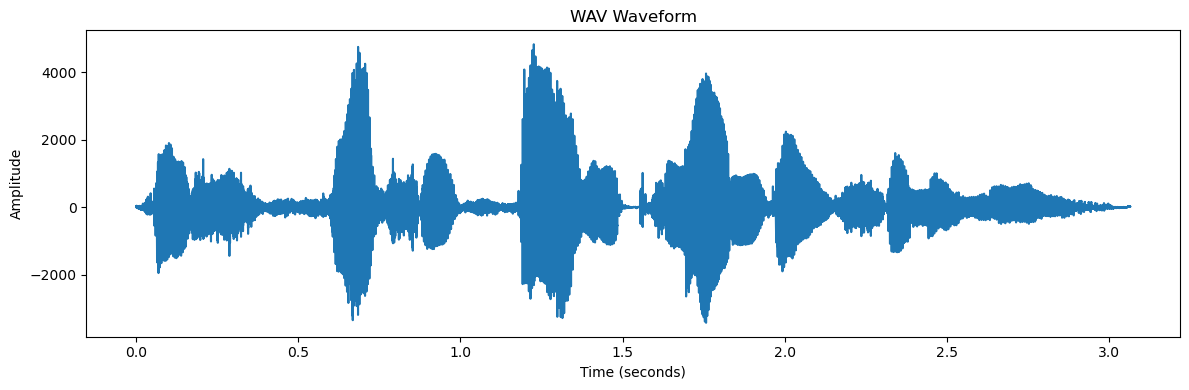

In [14]:
# Regular freq
wav_path = "../../data/audio/poem1_versuri/vers5.wav"
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=["tab:blue"])
visualize_wav(wav_path)

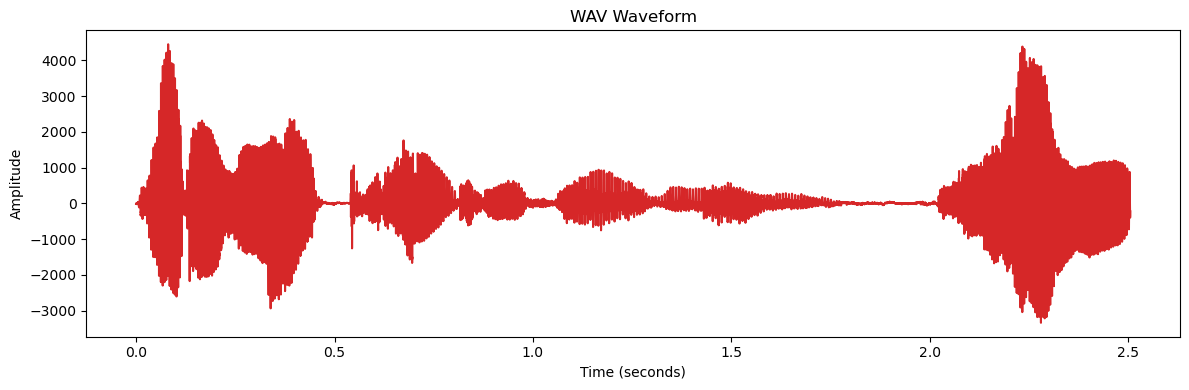

In [9]:
# irregular freq
wav_path = "../data/raw/poem1_versuri/vers1.wav"
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=["tab:red"])
visualize_wav(wav_path)

In [4]:
# plt.figure(figsize=(12, 5))
# plt.specgram(samples, Fs=sample_rate, NFFT=1024, noverlap=512)
# plt.xlabel("Time (seconds)")
# plt.ylabel("Frequency (Hz)")
# plt.title("Spectrogram")
# plt.colorbar(label="Intensity")
# plt.tight_layout()
# plt.show()

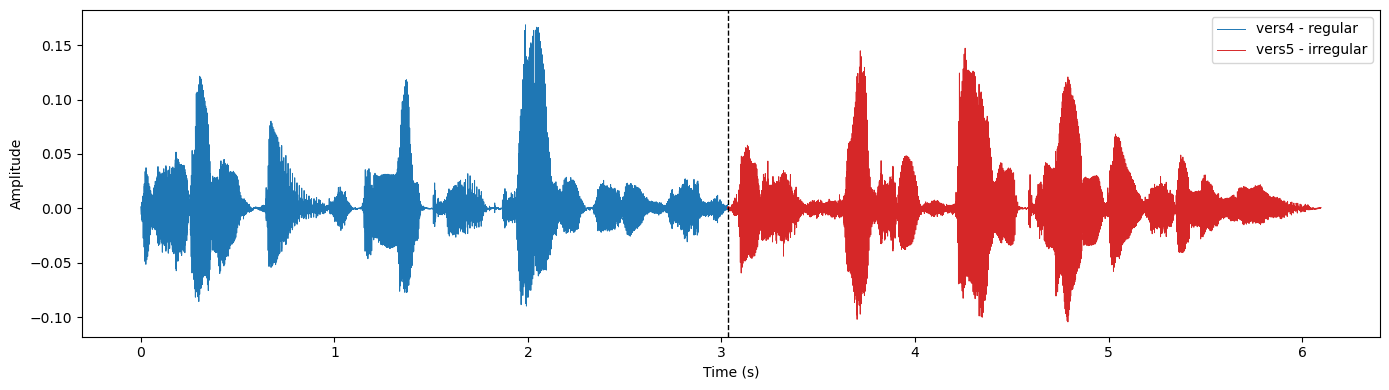

In [7]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

wav_path_1 = "../../data/audio/poem1_versuri/vers4.wav"  # label 1
wav_path_2 = "../../data/audio/poem1_versuri/vers5.wav"  # label 2


y1, sr = librosa.load(wav_path_1, sr=None)
y2, _ = librosa.load(wav_path_2, sr=sr)

# Time axes
t1 = np.arange(len(y1)) / sr
t2 = np.arange(len(y2)) / sr + len(y1) / sr

plt.figure(figsize=(14, 4))

plt.plot(t1, y1, color="tab:blue", linewidth=0.7, label="vers4 - regular")
plt.plot(t2, y2, color="tab:red", linewidth=0.7, label="vers5 - irregular")

boundary = len(y1) / sr
plt.axvline(boundary, color="black", linestyle="--", linewidth=1)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
# plt.title("Continuous stream: Label 1 → Label 2")
plt.legend()
plt.tight_layout()
plt.show()

# # Load both with the same sampling rate
# y1, sr = librosa.load(wav_path_1, sr=None)
# y2, _ = librosa.load(wav_path_2, sr=sr)

# # Concatenate → continuous stream
# y = np.concatenate([y1, y2])

# # Time axis
# t = np.arange(len(y)) / sr

# # Boundary between label 1 and label 2
# boundary = len(y1) / sr

# plt.figure(figsize=(14, 4))

# plt.plot(t, y, linewidth=0.7)

# # Mark transition
# plt.axvline(boundary, linestyle="--", linewidth=2, label="label 1 → label 2")

# # Label the two regions
# plt.text(boundary / 2, 0.9 * np.max(y), "vers4 - regular", ha="center")

# plt.text(
#     boundary + (t[-1] - boundary) / 2, 0.9 * np.max(y), "vers5 - irregular", ha="center"
# )

# plt.xlabel("Time (s)")
# plt.ylabel("Amplitude")
# plt.title("Continuous audio: vers2 → vers3")
# plt.legend()
# plt.tight_layout()
# plt.show()

## listen to continous 1-10

In [2]:
from pydub import AudioSegment

AudioSegment.from_wav("../../data/audio/poem1_versuri/vers1.wav")

In [ ]:
audio = AudioSegment.empty()

for i in range(1, 11):
    path = f"../../data/audio/poem1_versuri/vers{i}.wav"
    audio += AudioSegment.from_wav(path)

# Audio(audio.raw_data, rate=audio.frame_rate)
audio